In [ ]:
# IMPORT BLOCK

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(
    "/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot"
)

import sage_loader
from sage_loader import get_params, load_snapshot, load_variable, load_all_snapshots, load_variable_all_snapshots
from snapshot_redshift_mapper import SnapshotRedshiftMapper as z_mapper

In [2]:
## ARRAY REALIZATIONS
param_file = "/Users/pater32/Documents/GitHub/sage/GWRecoil/input/tng50.par"
galaxies_z0_1, volume_1, metadata_1 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1')
galaxies_z0_2, volume_2, metadata_2 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run2')
galaxies_z0_3, volume_3, metadata_3 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run3')
galaxies_z0_4, volume_4, metadata_4 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run4')
galaxies_z0_5, volume_5, metadata_5 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run5')
galaxies_z0_6, volume_6, metadata_6 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run6')
galaxies_z0_7, volume_7, metadata_7 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run7')
galaxies_z0_8, volume_8, metadata_8 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run8')
galaxies_z0_9, volume_9, metadata_9 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run9')
galaxies_z0_10, volume_10, metadata_10 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10')

## HELPER FUNCTIONS
def safe_div(numerator, denominator):
    if denominator > 0.0:
        return numerator/denominator
    else:
        return 0.0
    
def safe_log10(value):
    if value > 0:
        return np.log10(value)
    else:
        return np.nan

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000
Input files contain: 15618 trees, 22283 galaxies.
Reading 22283 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run2/model_z0.000
Input files contain: 15618 trees, 22283 galaxies.
Reading 22283 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run2/model_z0.000_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pate

In [3]:
## APPEND ALL GALAXY ARRAYS
galaxies_z0 = [
    galaxies_z0_1,
    galaxies_z0_2,
    galaxies_z0_3,
    galaxies_z0_4,
    galaxies_z0_5,
    galaxies_z0_6,
    galaxies_z0_7,
    galaxies_z0_8,
    galaxies_z0_9,
    galaxies_z0_10,
]

hubble_h = metadata_1['hubble_h']


[array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.89342591e-06,
       9.56996988e-03, 3.76661505e-02]), array([0.        , 0.        , 0.        , 0.00130544, 0.00320274,
       0.02420749])]


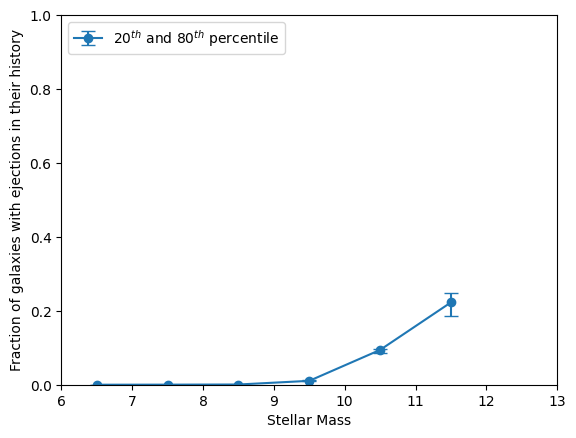

In [4]:
## EJECTION FRACTION PLOT WITH ERROR BARS

min_range = 6
max_range = 13
interval = 1
nbins = int((max_range - min_range) / interval)
mass_bins = np.arange(min_range, max_range, interval)

mass=[] # bin centers
bh_eject_fraction = {}
errors = []
for b in range(10):
        w = galaxies_z0[b].StellarMass > 0
        eject_mask = (galaxies_z0[b].StellarMass > 0) & (galaxies_z0[b].BHejectCount > 0)
        stellar_mass = np.log10(galaxies_z0[b].StellarMass[w] * 1e10 / hubble_h)
        stellar_mass_eject = np.log10(galaxies_z0[b].StellarMass[eject_mask] * 1e10 / hubble_h)

        for i in range(nbins - 1):
                # All galaxies_z0 in this mass bin
                this_bin_mask = (stellar_mass >= mass_bins[i]) & (stellar_mass < mass_bins[i + 1])
                this_bin_count = np.sum(this_bin_mask)
                # print(f'The number of galaxies in this mass bin {mass_bins[i]} - {mass_bins[i+1]}: {this_bin_count}')

                # galaxies_z0 that have had ejected black holes in this mass been
                bh_eject_mask = (stellar_mass_eject >= mass_bins[i]) & (stellar_mass_eject < mass_bins[i + 1])
                bh_eject_count = np.sum(bh_eject_mask)
                # print(f'The number of galaxies w ejected BHs in this mass bin {mass_bins[i]} - {mass_bins[i+1]}: {bh_eject_count}')

                # create ejection fraction list
                if b+1 not in bh_eject_fraction:
                        bh_eject_fraction[b+1] = {
                                'mass_bin': [],
                                'bh_eject_frac': []
                        }

                #Calculate occupation fraction
                bh_eject_frac = safe_div(bh_eject_count, this_bin_count)
                bh_eject_fraction[b+1]['bh_eject_frac'].append(bh_eject_frac)
                
                # Store the mass bin center
                mass_midpoint = (mass_bins[i] + mass_bins[i + 1]) / 2.0
                bh_eject_fraction[b+1]['mass_bin'].append(mass_midpoint)
                if b == 0:
                        mass.append(mass_midpoint)

all_fracs = np.array([bh_eject_fraction[run]['bh_eject_frac'] for run in bh_eject_fraction])
sorted_fracs = np.sort(all_fracs, axis=0)
fracs_median = np.median(all_fracs, axis=0)
fracs_20 = sorted_fracs[1]
fracs_80 = sorted_fracs[8]
errors = [fracs_median - fracs_20, fracs_80 - fracs_median]
print(errors)


plt.errorbar(mass, fracs_median, marker='o', yerr=errors, capsize=5, label = r'20$^{th}$ and 80$^{th}$ percentile')
plt.xlabel('Stellar Mass')
plt.ylabel('Fraction of galaxies with ejections in their history')
plt.xlim(min_range, max_range)
plt.ylim(0, 1)
plt.legend(loc='upper left')


In [ ]:
## Minimum galaxy mass ratio during merger (used to figure out if ejection frac difference comes from tng50_4 vs tng100_1 resolution difference)

data = load_all_snapshots(param_file)

gal_mrs = []
for snap in range(100):
    galaxies = data[snap][0]
    metadata = data[snap][2]

    array_length = len(galaxies)

    for i in range(array_length):
        gal_mass_ratio = galaxies.MassRatio[i]

        if gal_mass_ratio > 0.0:
            gal_mrs.append(gal_mass_ratio)


print(min(gal_mrs))


Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z20.050_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z14.990
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z14.990_0
Loaded 100 redshift values from /Users/pater